Dataset Preview:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0       11.0        1.0       11.0        5.0       11.0        1.0   
1        5.0        1.0        7.0        5.0        4.0        3.0   
2        4.0        2.0       13.0        8.0       13.0        3.0   
3        3.0        0.0       13.0       12.0       12.0        3.0   
4        9.0        0.0        6.0       11.0        3.0        4.0   

   Feature_7  Feature_8  Feature_9  Feature_10  Target  
0        3.0        6.0        6.0         1.0       1  
1        9.0        1.0        6.0         5.0       0  
2        0.0        6.0        1.0         4.0       1  
3        2.0        7.0        3.0         5.0       1  
4        2.0        0.0        6.0         2.0       2  

Model Coefficients:
Intercept: 1.270683967793564
Coefficients: [ 0.03973684 -0.11416758 -0.00659641  0.03586936 -0.00247161  0.02246814
 -0.10522061 -0.01198378 -0.014166    0.00093056]

Model Evaluation:
Mean Squ

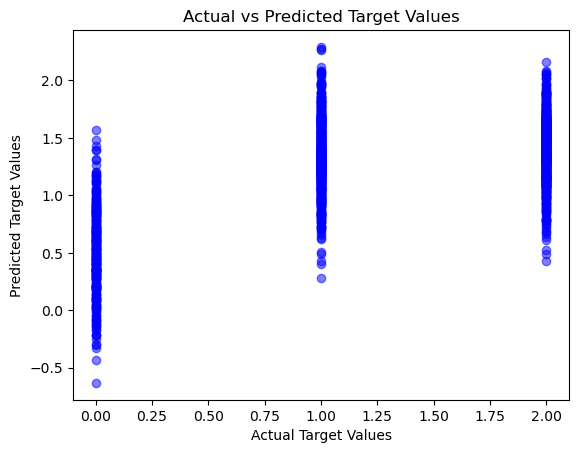

In [2]:

# Importing necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate the dataset
X, Y = make_multilabel_classification(n_samples=5000, n_features=10, n_classes=2, random_state=42)

# Convert Y into a continuous format for regression (sum of labels as continuous targets)
# For demonstration, you can replace this logic as per your regression objective
Y_continuous = Y.sum(axis=1)

# Convert the dataset into a DataFrame for better visualization
data = pd.DataFrame(X, columns=[f"Feature_{i+1}" for i in range(X.shape[1])])
data['Target'] = Y_continuous

# Display the first few rows of the dataset
print("Dataset Preview:")
print(data.head())

# Define independent variables (features) and dependent variable (target)
X_train, X_test, y_train, y_test = train_test_split(X, Y_continuous, test_size=0.3, random_state=42)

# Create and train the multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Model coefficients and intercept
print("\nModel Coefficients:")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

# Visualize the predicted vs actual values
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.xlabel("Actual Target Values")
plt.ylabel("Predicted Target Values")
plt.title("Actual vs Predicted Target Values")
#plt.grid()
plt.show()





In [4]:
# Load EDA Packages
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("netflix_titles.csv")
print(df.head())

# Class 1/Target 1/Output 1 Distribution
print(df['type'].value_counts())

# Class 2/Target 2/Output 2 Distribution
print(df['rating'].value_counts())

# Text Cleaning
import neattext.functions as nfx
df['title'] = df['title'].apply(nfx.lower)
df['title'] = df['title'].apply(nfx.remove_stopwords)
print(df.head())

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.multioutput import MultiOutputClassifier

# Features & Labels
Xfeatures = df['title']
ylabels = df[['type','rating']]

# Split Data
x_train, x_test, y_train, y_test = train_test_split(Xfeatures, ylabels, test_size=0.3, random_state=7)

from sklearn.pipeline import Pipeline
pipe_lr = Pipeline(steps=[
    ('cv', CountVectorizer()),
    ('lr_multi', MultiOutputClassifier(LogisticRegression()))
])

# Fit on Dataset
pipe_lr.fit(x_train, y_train)

# Accuracy Score
print("Accuracy Score:", pipe_lr.score(x_test, y_test))

# Sample Prediction
print(x_test.iloc[0])
print("Actual Prediction:", y_test.iloc[0])
pred1 = x_test.iloc[0]
print(pipe_lr.predict([pred1]))

# Prediction Probabilities
print(pipe_lr.classes_)
print(pipe_lr.predict_proba([pred1]))


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

ModuleNotFoundError: No module named 'neattext'